# Somalia workflow: Step 8: The multi-source trigger mechanism

Finalises the trigger structure agreed 2026-08-25, superseding the staged
design in notebook 10 (whose observed-SWALIM action legs were a stand-in):

1. **Both legs are forecast-based.** SWALIM is the ground truth the mechanism
   is calibrated and validated against — never a trigger input.
2. **Pooled station ranking.** Every (station, source) candidate from the
   three providers — GloFAS (v5 reanalysis / v4 reforecast), Google GRRR and
   GEOGloWS — competes on one skill metric against the SWALIM benchmark
   (notebook 06's correlations). One source per station so consensus stays
   spatial; the best source per station wins, with a timing guard (below).
3. **Action trigger, leads <= 6 days**: per basin (Juba / Shabelle), a
   season-specific N-of-8 station consensus over per-station RP thresholds.
   Calibrated so the two basins have **equal activation probability**
   (nominal ~1-in-4.3 each) and the **overall RP (either basin) >= 3 years**.
4. **Readiness trigger, leads 7-12 days**: GloFAS-only (the only provider
   with a forecast archive past 7 days — GRRR stops at 7, GEOGloWS has no
   reforecast). May activate more often than the action trigger.
5. Where a source has no historical forecast archive, its **reanalysis
   stands in for calibration** and the forecast leg is validated through a
   proxy with thresholds refit on the proxy's own climatology (the
   notebook-09 convention): GloFAS v5 windows are backtested through the v4
   reforecast; GEOGloWS could only be calibrated, never backtested, which is
   one reason it loses the ranking (see step A).

Inputs are the processed tables (restore with
`.venv/bin/python scripts/restore_from_blob.py`), including the new
`reforecast_glofas_v4_lead8_12` readiness band built by
`scripts/process_lead8_12.py`. Outputs: `som_ms_*` tables under
`processed/workflow/` and figures under `pages/trigger/figs/`.


In [1]:
import sys

sys.path.insert(0, "..")

import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import ocha_stratus as stratus

from src.constants import (
    SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_BAND,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import weibull_threshold

apply_chart_style()

DATA = Path("../data/processed")
FIGS = Path("../pages/trigger/figs")
FIGS.mkdir(parents=True, exist_ok=True)

def load(name):
    return pd.read_parquet(DATA / f"{name}.parquet")

def save_fig(fig, name):
    fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

YEARS = (1999, 2023)
N_YEARS = YEARS[1] - YEARS[0] + 1
YRS = set(range(YEARS[0], YEARS[1] + 1))
RP_LEVELS = [3, 4, 5, 6]     # per-station threshold grid (RP3+ rule, nb08)
RHO_TOL = 0.05               # sources within this of a station's best compete on timing
MIN_RHO = 0.5
TOP_N = 8
ACTION_MAX_LEAD = 6          # GloFAS "day" labels / GRRR leads (nb10 convention)
READY_LEADS = (7, 12)
GAUGE_BM = {"shabelle": "swalim_belet_weyne", "juba": "swalim_luuq"}
SOURCES = ["geoglows", "glofas_v5", "google_grrr"]

corr = load("workflow/som_gauge_correlations")
bench = load("workflow/som_flood_benchmark_seasonal")
dd = pd.concat(
    [load(f"discharge_daily_{s}").assign(file_source=s) for s in SOURCES],
    ignore_index=True,
)
dd["date"] = pd.to_datetime(dd["date"])

def bench_years(river, season, col="flood_3yr"):
    sub = bench[(bench.river == river) & (bench.benchmark == GAUGE_BM[river])
                & (bench.season == season) & (bench[col] == 1)]
    return set(sub.year) & YRS

def basin_bench(river, col):
    return bench_years(river, "gu", col) | bench_years(river, "deyr", col)


## A. Pooled station selection (all three providers, timing-aware)

Rank all 18 stations x 3 sources per river x season by best-lag Spearman rho
against the SWALIM reference gauge (notebook 06). Rule per station: among
sources within `RHO_TOL` of the station's best rho, prefer the **largest
best_lag** (the earliest signal), then rho. Rationale: a negative lag vs the
reference gauge is genuine travel time at stations downstream of it, but
where two sources tie on rho at the *same* station, the one whose signal
arrives days later (GEOGloWS trails by 4-10 days almost everywhere) burns
anticipation a <= 6-day forecast trigger cannot spare.

Then keep the top 8 stations per river x season with rho >= 0.5.


In [2]:
cand = corr[corr.benchmark == "swalim"].copy()
best = cand.groupby(["river", "season", "station"])["best_rho"].transform("max")
tied = cand[cand.best_rho >= best - RHO_TOL]
winners = (tied.sort_values(["best_lag", "best_rho"], ascending=False)
           .drop_duplicates(subset=["river", "season", "station"]))
sel = (winners[winners.best_rho >= MIN_RHO]
       .sort_values(["river", "season", "best_rho"], ascending=[1, 1, 0])
       .groupby(["river", "season"]).head(TOP_N)
       .reset_index(drop=True))
print(sel.groupby(["river", "season"]).source.value_counts().to_string())
print()
print("GEOGloWS selected anywhere:", (sel.source == "geoglows").any(),
      "- it ties GRRR on rho in Shabelle Gu but trails the gauge by 4-10 days")
sel


river     season  source     
juba      deyr    glofas_v5      8
          gu      google_grrr    8
shabelle  deyr    glofas_v5      8
          gu      google_grrr    8

GEOGloWS selected anywhere: False - it ties GRRR on rho in Shabelle Gu but trails the gauge by 4-10 days


,station,source,river,season,benchmark,best_rho,best_lag,n_obs
0,dollow,glofas_v5,juba,deyr,swalim,0.868,5,2087
1,luuq,glofas_v5,juba,deyr,swalim,0.849,3,2087
2,bardheere,glofas_v5,juba,deyr,swalim,0.805,0,2087
3,saakow,glofas_v5,juba,deyr,swalim,0.799,-1,2088
4,bualle,glofas_v5,juba,deyr,swalim,0.790,-2,2088
5,kaitoi,glofas_v5,juba,deyr,swalim,0.781,-3,2088
6,juba_05,glofas_v5,juba,deyr,swalim,0.778,-4,2088
7,juba_07,glofas_v5,juba,deyr,swalim,0.778,-5,2088
8,bardheere,google_grrr,juba,gu,swalim,0.869,-1,1999
9,saakow,google_grrr,juba,gu,swalim,0.868,-1,1999


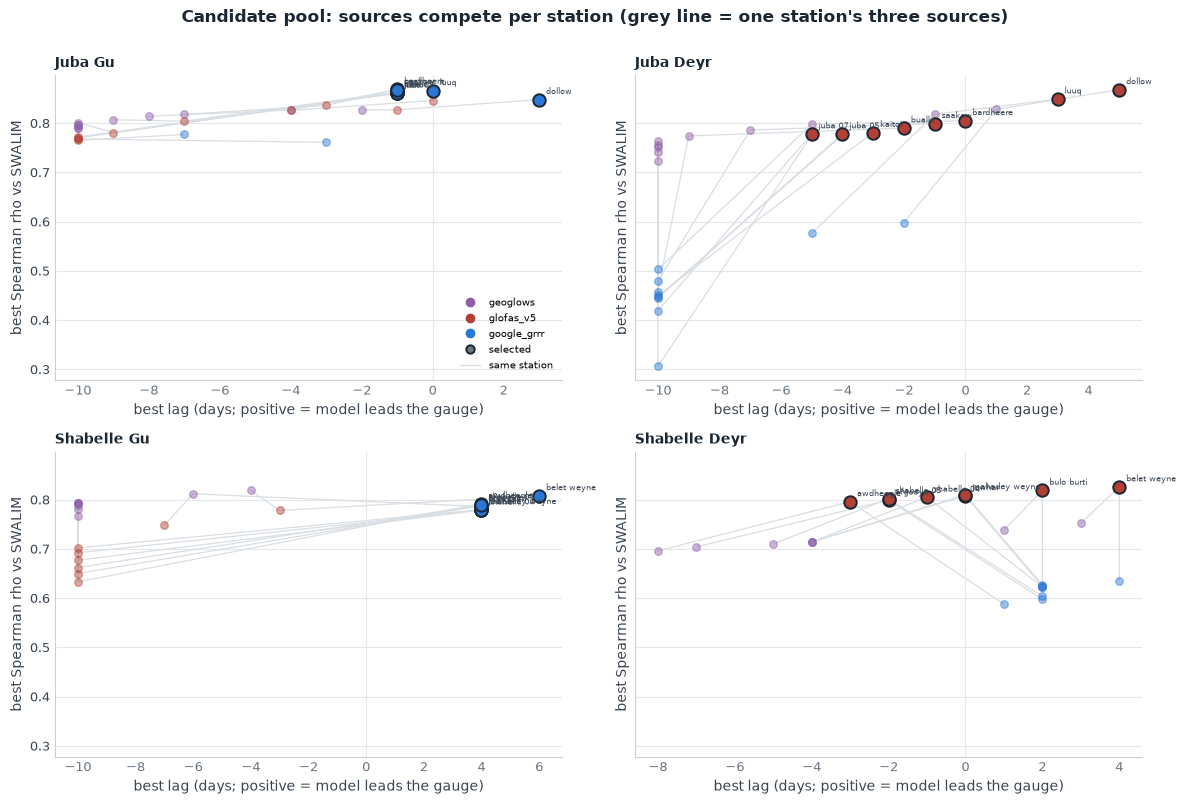

In [3]:
# Selection figure: dots of the SAME station are connected by a light line, so
# the one-source-per-station rule is visible — sources compete within a
# station, never across stations. The selected (station, source) is ring-marked.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
combos_fig = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
for ax, (river, season) in zip(axes.ravel(), combos_fig):
    sub = corr[(corr.benchmark == "swalim") & (corr.river == river) & (corr.season == season)]
    chosen = sel[(sel.river == river) & (sel.season == season)]
    keys = set(zip(chosen.station, chosen.source))
    # connect the (up to) three source dots per station
    for stn, g in sub.groupby("station"):
        g = g.sort_values("best_lag")
        ax.plot(g.best_lag, g.best_rho, color="#D9DEE3", lw=0.9, zorder=1)
    for src, grp in sub.groupby("source"):
        picked = grp.apply(lambda r: (r.station, r.source) in keys, axis=1)
        ax.scatter(grp[~picked].best_lag, grp[~picked].best_rho,
                   color=SOURCE_COLORS[src], alpha=0.45, s=30, zorder=3)
        ax.scatter(grp[picked].best_lag, grp[picked].best_rho,
                   color=SOURCE_COLORS[src], s=80, edgecolors=INK, linewidths=1.4,
                   zorder=4)
    for _, r in chosen.iterrows():
        ax.annotate(r.station.replace("_", " "), (r.best_lag, r.best_rho),
                    textcoords="offset points", xytext=(5, 4), fontsize=5.8,
                    color=BODY, zorder=5)
    ax.axvline(0, color=GRID, lw=0.8)
    ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
    ax.set_xlabel("best lag (days; positive = model leads the gauge)")
    ax.set_ylabel("best Spearman rho vs SWALIM")
    style_ax(ax, grid="y")
handles = [plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="", label=s)
           for s in SOURCES] + [
    plt.Line2D([], [], color=FAINT, marker="o", ls="", markeredgecolor=INK,
               markeredgewidth=1.4, label="selected"),
    plt.Line2D([], [], color="#D9DEE3", lw=1, label="same station"),
]
axes.ravel()[0].legend(handles=handles, fontsize=7.5, loc="lower right")
fig.suptitle("Candidate pool: sources compete per station (grey line = one station's three sources)",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()
save_fig(fig, "a_selection")


### The station network

The registry (18 monitoring points, GloFAS-grid-verified coordinates with
per-provider ID mappings, `src/constants.py`) and the river buffers are
Pauline Wairimu's; the map shows which provider carries each station in the
adopted mechanism, per season window.


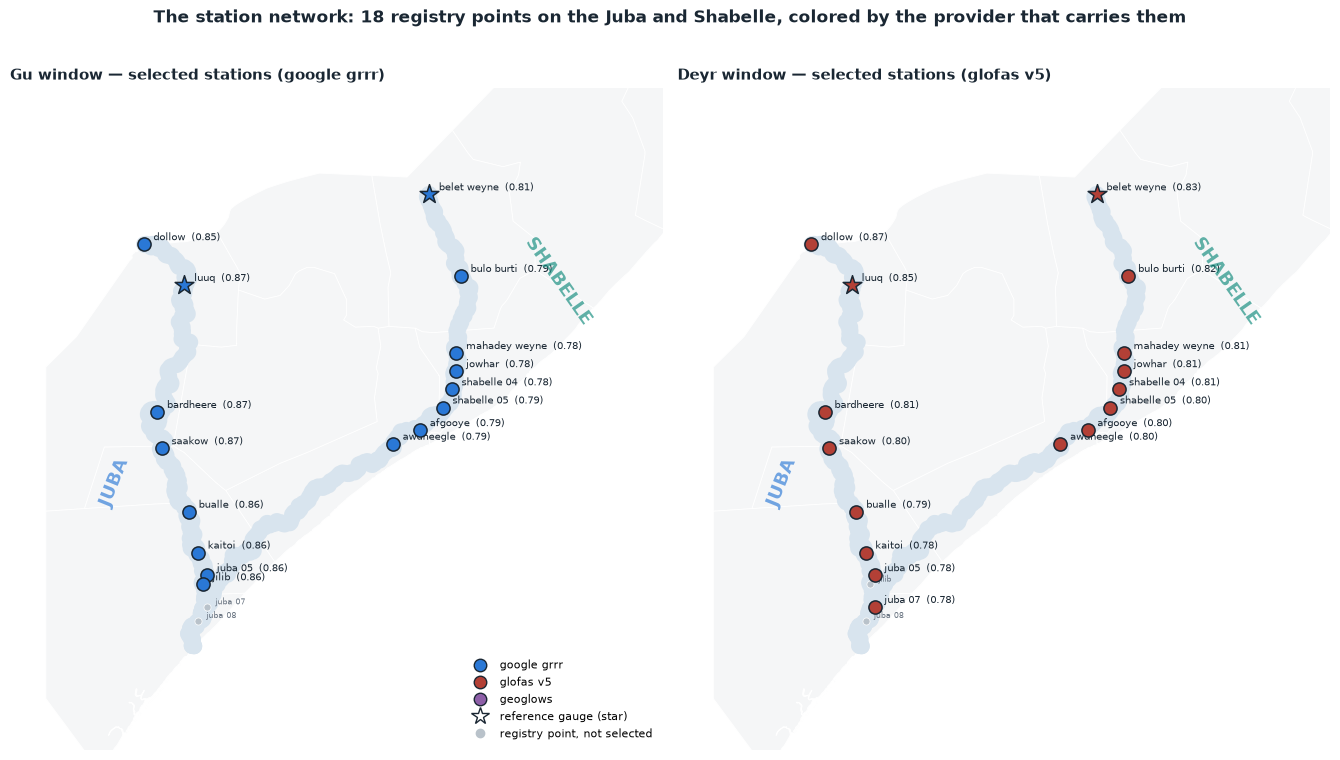

In [4]:
import os
import tempfile

import geopandas as gpd

adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 8.2))
for ax, season in zip(axes, ["gu", "deyr"]):
    adm1.plot(ax=ax, color="#F5F6F7", edgecolor="white", linewidth=0.6)
    bufs.plot(ax=ax, color="#D8E4EE")
    chosen = sel[sel.season == season].set_index("station")
    for key, st in STATIONS.items():
        if key in chosen.index:
            r = chosen.loc[key]
            is_ref = key in ("belet_weyne", "luuq")
            ax.scatter(st.lon, st.lat, s=200 if is_ref else 90,
                       marker="*" if is_ref else "o",
                       color=SOURCE_COLORS[r.source], edgecolors=INK,
                       linewidths=1.1, zorder=6 if is_ref else 5)
            ax.annotate(f"{key.replace('_', ' ')}  ({r.best_rho:.2f})",
                        (st.lon, st.lat), textcoords="offset points",
                        xytext=(7, 3), fontsize=7, color=INK)
        else:
            ax.scatter(st.lon, st.lat, s=26, color="#B9C2CA",
                       edgecolors="white", linewidths=0.5, zorder=4)
            ax.annotate(key.replace("_", " "), (st.lon, st.lat),
                        textcoords="offset points", xytext=(6, 2),
                        fontsize=6, color=FAINT)
    ax.text(41.55, 1.30, "JUBA", fontsize=13, fontweight="bold",
            color=C_JUBA, alpha=0.65, rotation=68)
    ax.text(46.25, 3.30, "SHABELLE", fontsize=13, fontweight="bold",
            color=C_SHAB, alpha=0.65, rotation=-55)
    src_here = sel[sel.season == season].source.unique()
    ax.set_title(f"{season.capitalize()} window — selected stations "
                 f"({', '.join(s.replace('_', ' ') for s in src_here)})",
                 loc="left", fontsize=11)
    ax.set_xlim(40.6, 47.8)
    ax.set_ylim(-1.4, 5.9)
    ax.set_axis_off()
handles = ([plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="",
                       markersize=9, markeredgecolor=INK, label=s.replace("_", " "))
            for s in ["google_grrr", "glofas_v5", "geoglows"]]
           + [plt.Line2D([], [], color=INK, marker="*", ls="", markersize=13,
                         markerfacecolor="white", label="reference gauge (star)"),
              plt.Line2D([], [], color="#B9C2CA", marker="o", ls="", markersize=6,
                         label="registry point, not selected")])
axes[0].legend(handles=handles, fontsize=8, loc="lower right")
fig.suptitle("The station network: 18 registry points on the Juba and Shabelle, "
             "colored by the provider that carries them",
             fontweight="bold", color=INK, fontsize=12.5, y=0.98)
plt.tight_layout()
save_fig(fig, "map_stations")


In [5]:
# per-station selection detail -> pages/trigger/selection_detail.json
detail = {}
for (river, season), grp in corr[corr.benchmark == "swalim"].groupby(["river", "season"]):
    chosen = sel[(sel.river == river) & (sel.season == season)]
    keys = set(zip(chosen.station, chosen.source))
    rows = []
    for stn, g in grp.groupby("station"):
        row = {"station": stn}
        for src in SOURCES:
            m = g[g.source == src]
            row[src] = ({"rho": round(float(m.best_rho.iloc[0]), 3),
                         "lag": int(m.best_lag.iloc[0])} if len(m) else None)
        picked = [s for s in SOURCES if (stn, s) in keys]
        row["selected"] = picked[0] if picked else None
        rows.append(row)
    order = {s: i for i, s in enumerate(chosen.station)}
    rows.sort(key=lambda r: (order.get(r["station"], 99), r["station"]))
    detail[f"{river}_{season}"] = rows
(FIGS.parent / "selection_detail.json").write_text(json.dumps(detail, separators=(",", ":")))
print("wrote pages/trigger/selection_detail.json")


wrote pages/trigger/selection_detail.json


## B. Per-station thresholds (seasonal Weibull, each source's own climatology)

Each selected (station, source) gets thresholds at RP 3-6 from Weibull
plotting positions on its own seasonal maxima 1999-2023 (log-log
interpolation, `weibull_threshold`) — so every station is equally likely to
exceed its threshold by construction, and each source is judged against its
own climatology (magnitude bias between sources cancels out).


In [6]:
daily, th_rows = {}, []
for _, r in sel.iterrows():
    s = dd[(dd.file_source == r.source) & (dd.station == r.station)].set_index("date")["discharge"]
    s = s[s.index.month.isin(SEASONS[r.season])]
    s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
    daily[(r.river, r.season, r.station)] = s
    am = s.groupby(s.index.year).max().dropna()
    row = {"river": r.river, "season": r.season, "station": r.station, "source": r.source}
    for rp in RP_LEVELS:
        row[f"rp{rp}"] = weibull_threshold(am.values, rp)
    th_rows.append(row)
th = pd.DataFrame(th_rows)
th.round(1)


,river,season,station,source,rp3,rp4,rp5,rp6
0,juba,deyr,dollow,glofas_v5,563.6,600.9,659.1,683.0
1,juba,deyr,luuq,glofas_v5,836.9,972.9,1070.6,1081.2
2,juba,deyr,bardheere,glofas_v5,869.3,965.9,1032.8,1054.3
3,juba,deyr,saakow,glofas_v5,846.3,943.4,1004.9,1033.5
4,juba,deyr,bualle,glofas_v5,774.2,870.7,916.7,931.5
5,juba,deyr,kaitoi,glofas_v5,722.2,823.7,853.2,884.7
6,juba,deyr,juba_05,glofas_v5,704.3,807.4,831.1,868.2
7,juba,deyr,juba_07,glofas_v5,765.9,823.2,870.9,1055.2
8,juba,gu,bardheere,google_grrr,292.2,345.9,377.0,436.1
9,juba,gu,saakow,google_grrr,283.8,335.8,386.6,435.3


## C. Action trigger: per-window grids and the basin-level search

Per river x season, a season-year **activates** when on >= 1 day of the
season >= N of the 8 stations simultaneously exceed their RP threshold (the
notebook-08 rule). Many (RP, N) pairs produce identical activation-year
sets, so the search runs at the **basin level**: for every combination of a
Gu config and a Deyr config, the basin's activation years are their union.

Feasibility and scoring (agreed 2026-08-25):
- **basin activation count 4-6 in 25 years** (RP 4.3-6.5; nominal ~1-in-5,
  final threshold adjustment left to the framework working group);
- maximize **coverage of the basin's severe (1-in-5) benchmark years**;
- minimize **activations outside the moderate (1-in-3) benchmark set**;
- among ties, prefer the consensus fraction nearest 0.75 (a spatial-noise
  filter that no single station can dominate, robust to one gauge failing —
  the Nigeria consideration), then the lower per-station RP.


In [7]:
acts = {}
for (river, season), grp in sel.groupby(["river", "season"]):
    stations = grp.station.tolist()
    for rp in RP_LEVELS:
        mat = pd.concat(
            [(daily[(river, season, stn)]
              >= th[(th.river == river) & (th.season == season)
                    & (th.station == stn)][f"rp{rp}"].iloc[0]).rename(stn)
             for stn in stations],
            axis=1).fillna(False)
        mx = mat.sum(axis=1).groupby(mat.index.year).max()
        for n in range(2, TOP_N + 1):        # n >= 2: no single-station trigger
            acts[(river, season, rp, n)] = frozenset(mx[mx >= n].index)

def tie_key(rp_g, n_g, rp_d, n_d):
    frac_pen = abs(n_g / TOP_N - 0.75) + abs(n_d / TOP_N - 0.75)
    return (frac_pen, rp_g + rp_d)

grid_rows = []
for river in ["juba", "shabelle"]:
    sev, mod = basin_bench(river, "flood_5yr"), basin_bench(river, "flood_3yr")
    for (rp_g, n_g), (rp_d, n_d) in itertools.product(
            itertools.product(RP_LEVELS, range(2, TOP_N + 1)), repeat=2):
        a = acts[(river, "gu", rp_g, n_g)] | acts[(river, "deyr", rp_d, n_d)]
        grid_rows.append({
            "river": river, "gu_rp": rp_g, "gu_n": n_g, "deyr_rp": rp_d, "deyr_n": n_d,
            "n_act": len(a), "basin_rp": (N_YEARS + 1) / len(a) if a else np.inf,
            "pod_severe": len(a & sev) / len(sev),
            "n_false": len(a - mod), "years": tuple(sorted(a)),
            "tie": tie_key(rp_g, n_g, rp_d, n_d),
        })
grid = pd.DataFrame(grid_rows)

adopted = {}
for river in ["juba", "shabelle"]:
    feas = grid[(grid.river == river) & grid.n_act.between(4, 6)]
    pick = feas.sort_values(["pod_severe", "n_false", "tie"],
                            ascending=[False, True, True]).iloc[0]
    adopted[river] = pick
    print(f"{river}: Gu RP{pick.gu_rp} >={pick.gu_n}/8 | Deyr RP{pick.deyr_rp} >={pick.deyr_n}/8"
          f" -> {pick.n_act} activations (RP {pick.basin_rp:.1f}),"
          f" severe coverage {pick.pod_severe:.2f}, {pick.n_false} outside 1-in-3 set")
    print(f"   activation years: {list(pick.years)}")

union = set(adopted['juba'].years) | set(adopted['shabelle'].years)
overall_rp = (N_YEARS + 1) / len(union)
print(f"\nOVERALL (either basin): {len(union)} of {N_YEARS} years -> RP {overall_rp:.1f}"
      f" (target >= 3.0): {sorted(union)}")


juba: Gu RP6 >=6/8 | Deyr RP6 >=6/8 -> 6 activations (RP 4.3), severe coverage 0.62, 0 outside 1-in-3 set
   activation years: [2006, 2013, 2016, 2018, 2020, 2023]
shabelle: Gu RP6 >=6/8 | Deyr RP6 >=7/8 -> 6 activations (RP 4.3), severe coverage 0.57, 1 outside 1-in-3 set
   activation years: [2006, 2013, 2018, 2019, 2020, 2023]

OVERALL (either basin): 7 of 25 years -> RP 3.7 (target >= 3.0): [2006, 2013, 2016, 2018, 2019, 2020, 2023]


In [8]:
# the adopted per-leg configuration, with per-station thresholds
CONFIG = {}
for river, pick in adopted.items():
    for season, rp, n in [("gu", pick.gu_rp, pick.gu_n), ("deyr", pick.deyr_rp, pick.deyr_n)]:
        grp = sel[(sel.river == river) & (sel.season == season)]
        CONFIG[(river, season)] = {
            "source": grp.source.iloc[0] if grp.source.nunique() == 1 else "mixed",
            "stations": grp.station.tolist(), "rp": int(rp), "n_req": int(n),
            "years": sorted(acts[(river, season, rp, n)]),
        }
cfg_rows = []
for (river, season), c in CONFIG.items():
    for stn in c["stations"]:
        r = sel[(sel.river == river) & (sel.season == season) & (sel.station == stn)].iloc[0]
        cfg_rows.append({
            "river": river, "season": season, "station": stn, "source": r.source,
            "best_rho": r.best_rho, "best_lag": int(r.best_lag),
            "rp_threshold_years": c["rp"],
            "threshold_m3s": round(th[(th.river == river) & (th.season == season)
                                      & (th.station == stn)][f"rp{c['rp']}"].iloc[0], 1),
            "n_stations_required": c["n_req"], "n_stations_total": len(c["stations"]),
            "max_leadtime_days": ACTION_MAX_LEAD,
        })
cfg_df = pd.DataFrame(cfg_rows)
leg_tab = (cfg_df.groupby(["river", "season", "source", "rp_threshold_years",
                           "n_stations_required"]).size().rename("n_stations").reset_index())
leg_tab["activation_years"] = leg_tab.apply(
    lambda r: CONFIG[(r.river, r.season)]["years"], axis=1)
leg_tab["leg_rp"] = leg_tab.activation_years.apply(lambda y: round((N_YEARS + 1) / max(len(y), 1), 1))
leg_tab


,river,season,source,rp_threshold_years,n_stations_required,n_stations,activation_years,leg_rp
0,juba,deyr,glofas_v5,6,6,8,"[2006, 2023]",13.0
1,juba,gu,google_grrr,6,6,8,"[2013, 2016, 2018, 2020]",6.5
2,shabelle,deyr,glofas_v5,6,7,8,"[2006, 2019, 2023]",8.7
3,shabelle,gu,google_grrr,6,6,8,"[2013, 2018, 2020]",8.7


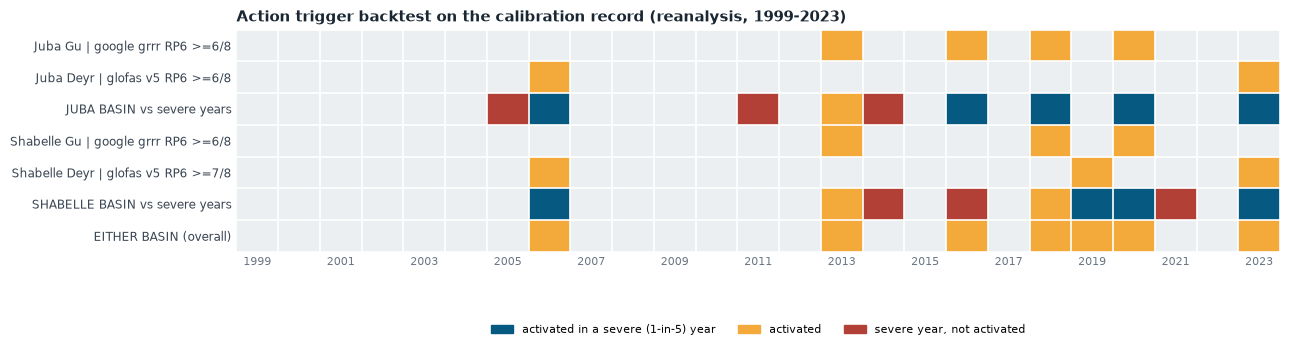

In [9]:
years = list(range(YEARS[0], YEARS[1] + 1))
rows_m, labels = [], []
for river in ["juba", "shabelle"]:
    sev, mod = basin_bench(river, "flood_5yr"), basin_bench(river, "flood_3yr")
    for season in ["gu", "deyr"]:
        c = CONFIG[(river, season)]
        a = set(c["years"])
        rows_m.append([2 if y in a else 0 for y in years])
        labels.append(f"{river.capitalize()} {season.capitalize()} | {c['source'].replace('_', ' ')} "
                      f"RP{c['rp']} >={c['n_req']}/8")
    a = set(adopted[river].years)
    rows_m.append([3 if (y in a and y in sev) else (2 if y in a else (1 if y in sev else 0))
                   for y in years])
    labels.append(f"{river.upper()} BASIN vs severe years")
rows_m.append([2 if y in union else 0 for y in years])
labels.append("EITHER BASIN (overall)")

cmap = mcolors.ListedColormap(["#ECEFF1", "#B34036", "#F4A93B", "#065A82"])
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.imshow(rows_m, cmap=cmap, vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(0, len(years), 2)); ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color="#065A82", label="activated in a severe (1-in-5) year"),
    mpatches.Patch(color="#F4A93B", label="activated"),
    mpatches.Patch(color="#B34036", label="severe year, not activated"),
], loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=8)
ax.set_title("Action trigger backtest on the calibration record (reanalysis, 1999-2023)",
             fontsize=11)
plt.tight_layout()
save_fig(fig, "c_backtest_strip")


## D. Return-period bookkeeping (methods/return-periods.md)

Individual (per leg), per basin, and overall. Funding note: under the
working assumption that the full envelope is released on any activation
(all-in, as in Pauline's evidence deck), the **effective RP equals the
overall RP**; a split structure would push effective above overall. That
remains a framework-team decision.


In [10]:
rp_rows = []
for (river, season), c in CONFIG.items():
    rp_rows.append({"level": "individual", "trigger": f"{river} {season} action",
                    "n_act": len(c["years"]), "rp_yr": round((N_YEARS + 1) / max(len(c["years"]), 1), 1)})
for river, pick in adopted.items():
    rp_rows.append({"level": "basin", "trigger": f"{river} action (Gu or Deyr)",
                    "n_act": pick.n_act, "rp_yr": round(pick.basin_rp, 1)})
rp_rows.append({"level": "overall", "trigger": "action, either basin",
                "n_act": len(union), "rp_yr": round(overall_rp, 1)})
rp_tab = pd.DataFrame(rp_rows)
assert rp_tab[rp_tab.level == "overall"].rp_yr.iloc[0] <= rp_tab[rp_tab.level == "basin"].rp_yr.min()
rp_tab


,level,trigger,n_act,rp_yr
0,individual,juba gu action,4,6.5
1,individual,juba deyr action,2,13.0
2,individual,shabelle gu action,3,8.7
3,individual,shabelle deyr action,3,8.7
4,basin,juba action (Gu or Deyr),6,4.3
5,basin,shabelle action (Gu or Deyr),6,4.3
6,overall,"action, either basin",7,3.7


## E. Reforecast backtest of the action legs (leads <= 6 days)

What the trigger would actually have seen operationally. Per station and
issue date, the <= 6-day forecast: GloFAS = 11-member ensemble **median**
(the >= 50%-of-members rule) per (station, issue, valid day); GRRR is
deterministic. A leg activates operationally in a season-year when at least
one **issue date** sees >= N stations over threshold on the same valid day —
the consensus must be visible in a single forecast product, exactly as a
monitoring pipeline would evaluate it.

Provider archives differ (the notebook-09 convention):
- **Gu legs (GRRR)**: own reforecast, 2016-2023, same thresholds as the
  calibration (GRRR's forecast climatology matches its reanalysis, nb03).
- **Deyr legs (GloFAS v5)**: no v5 reforecast exists, so the **v4 reforecast**
  stands in, with thresholds refit on v4's own reanalysis climatology at the
  same RP (judging the forecast against a frequency-consistent baseline).
- **GEOGloWS**: no reforecast at all — its short 2024+ forecast archive and
  the forecast-vs-retrospective bias (runs 0.6-0.7x, nb03) are exactly why
  it could not win a forecast-trigger slot.


In [11]:
rf_grrr = load("reforecast_google_grrr")
rf_gf = load("reforecast_glofas_v4")
for df in (rf_grrr, rf_gf):
    df["valid_time"] = pd.to_datetime(df["valid_time"])
    df["issued_time"] = pd.to_datetime(df["issued_time"])

# per (station, issue, valid): the <= 6-day signal
gf_a = (rf_gf[rf_gf.leadtime_days <= ACTION_MAX_LEAD]
        .groupby(["station", "issued_time", "valid_time"])["discharge"].median()
        .rename("q").reset_index())
gr_a = (rf_grrr[(rf_grrr.leadtime_days >= 1) & (rf_grrr.leadtime_days <= ACTION_MAX_LEAD)]
        .groupby(["station", "issued_time", "valid_time"])["discharge"].max()
        .rename("q").reset_index())
RF = {"google_grrr": gr_a, "glofas_v4": gf_a}
RF_YEARS = {"google_grrr": (2016, 2023), "glofas_v4": (2003, 2023)}

dd_gf4 = load("discharge_daily_glofas_v4")
dd_gf4["date"] = pd.to_datetime(dd_gf4["date"])

def refit_thresholds(river, season, rp):
    ths = {}
    for stn in CONFIG[(river, season)]["stations"]:
        s = dd_gf4[dd_gf4.station == stn].set_index("date")["discharge"]
        s = s[s.index.month.isin(SEASONS[season])]
        s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
        am = s.groupby(s.index.year).max().dropna()
        if len(am):
            ths[stn] = weibull_threshold(am.values, rp)
    return ths

RF_PROXY = {"google_grrr": "google_grrr", "glofas_v5": "glofas_v4"}
rf_backtest = {}
rf_rows = []
for (river, season), c in CONFIG.items():
    rf_source = RF_PROXY[c["source"]]
    y0, y1 = RF_YEARS[rf_source]
    if rf_source == c["source"]:
        ths = {r.station: r.threshold_m3s for _, r in
               cfg_df[(cfg_df.river == river) & (cfg_df.season == season)].iterrows()}
    else:
        ths = refit_thresholds(river, season, c["rp"])
    d = RF[rf_source]
    d = d[d.station.isin(ths) & d.valid_time.dt.month.isin(SEASONS[season])].copy()
    d["over"] = d.q >= d.station.map(ths)
    n_by_issue_valid = d.groupby(["issued_time", "valid_time"])["over"].sum()
    qual = n_by_issue_valid[n_by_issue_valid >= c["n_req"]].reset_index()
    act_years = sorted(set(qual.valid_time.dt.year))
    first_issue = qual.groupby(qual.valid_time.dt.year).issued_time.min()
    ra_years = [y for y in c["years"] if y0 <= y <= y1]
    n_stations_missing = len(c["stations"]) - len(ths)
    rf_backtest[(river, season)] = {"act_years": act_years, "first_issue": first_issue,
                                    "window": (y0, y1)}
    rf_rows.append({
        "river": river, "season": season, "source": c["source"], "rf_source": rf_source,
        "rf_window": f"{y0}-{y1}", "stations_missing_in_rf": n_stations_missing,
        "reforecast_activations": act_years,
        "reanalysis_activations_same_window": ra_years,
        "agree": sorted(set(act_years) & set(ra_years)),
        "rf_only": sorted(set(act_years) - set(ra_years)),
        "ra_only": sorted(set(ra_years) - set(act_years)),
    })
rf_tab = pd.DataFrame(rf_rows)
rf_tab


,river,season,source,rf_source,rf_window,stations_missing_in_rf,reforecast_activations,reanalysis_activations_same_window,agree,rf_only,ra_only
0,juba,gu,google_grrr,google_grrr,2016-2023,0,"[2016, 2018, 2020]","[2016, 2018, 2020]","[2016, 2018, 2020]",[],[]
1,juba,deyr,glofas_v5,glofas_v4,2003-2023,0,"[2017, 2023]","[2006, 2023]",[2023],[2017],[2006]
2,shabelle,gu,google_grrr,google_grrr,2016-2023,0,"[2016, 2018, 2020]","[2018, 2020]","[2018, 2020]",[2016],[]
3,shabelle,deyr,glofas_v5,glofas_v4,2003-2023,0,"[2013, 2019]","[2006, 2019, 2023]",[2019],[2013],"[2006, 2023]"


### Per-event operational anticipation

For each reforecast activation year: days between the **first issue date**
on which the consensus was visible and the season's first SWALIM
reference-gauge crossing of its official Moderate flood-risk level (the
event-onset proxy). Positive = the trigger preceded the observed crossing.
Years where the gauge never crossed Moderate have no onset to anticipate
(the activation was a false alarm or a below-Moderate season).


In [12]:
lv = load("swalim_levels"); lv["date"] = pd.to_datetime(lv["date"])
sw_th = load("swalim_thresholds").set_index("station")
REF_GAUGE = {"shabelle": "belet_weyne", "juba": "luuq"}

lead_rows = []
for (river, season), c in CONFIG.items():
    gauge = REF_GAUGE[river]
    mod_level = sw_th.loc[gauge, "moderate_flood_risk"]
    s = lv[lv.station == gauge].set_index("date")["level_m"]
    s = s[s.index.month.isin(SEASONS[season])]
    bt = rf_backtest[(river, season)]
    for y, issue in bt["first_issue"].items():
        cross = s[(s.index.year == y) & (s >= mod_level)]
        onset = cross.index.min() if len(cross) else pd.NaT
        lead_rows.append({
            "river": river, "season": season, "year": int(y),
            "first_trigger_issue": issue.date(),
            "swalim_moderate_onset": onset.date() if pd.notna(onset) else None,
            "anticipation_days": (onset - issue).days if pd.notna(onset) else np.nan,
        })
lead_tab = pd.DataFrame(lead_rows).sort_values(["river", "season", "year"])
lead_tab


,river,season,year,first_trigger_issue,swalim_moderate_onset,anticipation_days
3,juba,deyr,2017,2017-10-23,None,NaN
4,juba,deyr,2023,2023-10-21,2023-10-05,-16.0
0,juba,gu,2016,2016-05-05,2016-04-30,-5.0
1,juba,gu,2018,2018-04-18,2018-04-18,0.0
2,juba,gu,2020,2020-04-25,2020-05-12,17.0
8,shabelle,deyr,2013,2013-10-09,2013-10-28,19.0
9,shabelle,deyr,2019,2019-10-02,2019-10-13,11.0
5,shabelle,gu,2016,2016-05-01,2016-05-05,4.0
6,shabelle,gu,2018,2018-04-27,2018-04-19,-8.0
7,shabelle,gu,2020,2020-04-24,2020-04-29,5.0


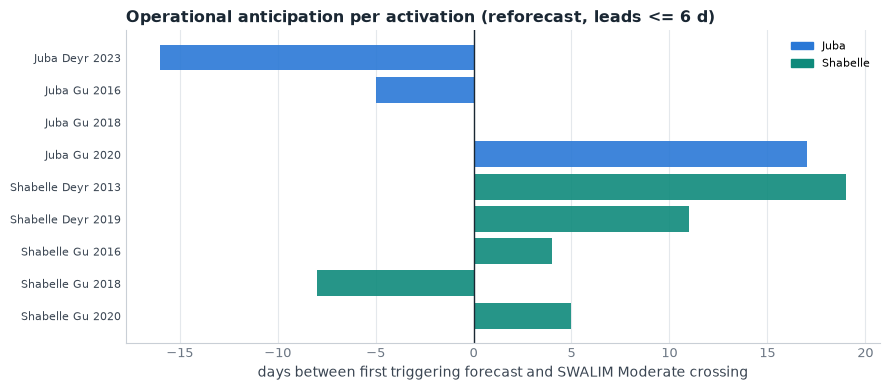

In [13]:
sub = lead_tab.dropna(subset=["anticipation_days"])
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"juba": C_JUBA, "shabelle": C_SHAB}
for i, (_, r) in enumerate(sub.iterrows()):
    ax.barh(i, r.anticipation_days, color=colors[r.river], alpha=0.9)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels([f"{r.river.capitalize()} {r.season.capitalize()} {r.year}"
                    for _, r in sub.iterrows()], fontsize=8)
ax.axvline(0, color=INK, lw=1)
ax.invert_yaxis()
ax.set_xlabel("days between first triggering forecast and SWALIM Moderate crossing")
ax.set_title("Operational anticipation per activation (reforecast, leads <= 6 d)")
ax.legend(handles=[mpatches.Patch(color=C_JUBA, label="Juba"),
                   mpatches.Patch(color=C_SHAB, label="Shabelle")], fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "e_anticipation")


## F. Readiness trigger (GloFAS, leads 7-12 days)

The 7-12 day band is GloFAS-only. Forecast: v4 reforecast leads 7 (from the
leads-1-7 archive) and 8-12 (the new `reforecast_glofas_v4_lead8_12` table,
extended box, so juba_07/08 are covered from lead 8). Ensemble median per
(station, issue, valid), best signal across the band per issue, thresholds
on v4's own reanalysis climatology. Same station sets as the action legs.

Readiness may fire more often than action (it releases only the small
mobilisation share). Search RP {2, 3} x N, target activation RP 2.5-4.5,
maximize coverage of the leg's action years (its job is to precede action),
tie-break to the least frequent.


In [14]:
rf812 = load("reforecast_glofas_v4_lead8_12")
rf812["valid_time"] = pd.to_datetime(rf812["valid_time"])
rf812["issued_time"] = pd.to_datetime(rf812["issued_time"])
band = pd.concat([rf_gf[rf_gf.leadtime_days.between(*READY_LEADS)],
                  rf812[rf812.leadtime_days.between(*READY_LEADS)]], ignore_index=True)
band_sig = (band.groupby(["station", "issued_time", "valid_time"])["discharge"].median()
            .rename("q").reset_index())
print(f"readiness band: leads {sorted(band.leadtime_days.unique())}, "
      f"{band_sig.station.nunique()} stations, issues "
      f"{band.issued_time.min().date()} -> {band.issued_time.max().date()}")

ready_rows = []
for (river, season), c in CONFIG.items():
    months = SEASONS[season]
    action_years = set(c["years"]) & set(range(2003, 2024))
    for rp in (2, 3):
        ths = refit_thresholds(river, season, rp)
        d = band_sig[band_sig.station.isin(ths)
                     & band_sig.valid_time.dt.month.isin(months)].copy()
        d["over"] = d.q >= d.station.map(ths)
        n_iv = d.groupby(["issued_time", "valid_time"])["over"].sum()
        for n in range(2, TOP_N + 1):
            qual = n_iv[n_iv >= n].reset_index()
            act = sorted(set(qual.valid_time.dt.year))
            ready_rows.append({
                "river": river, "season": season, "rp": rp, "n_req": n,
                "n_stations": len(ths), "n_act": len(act),
                "rp_act": round(22 / max(len(act), 1), 1),
                "action_coverage": (len(set(act) & action_years) / len(action_years)
                                    if action_years else np.nan),
                "years": act,
            })
ready_grid = pd.DataFrame(ready_rows)

READY = {}
for (river, season), grp in ready_grid.groupby(["river", "season"]):
    feas = grp[grp.rp_act.between(2.5, 4.5)]
    if not len(feas):
        feas = grp
    pick = feas.sort_values(["action_coverage", "rp_act"], ascending=[False, False]).iloc[0]
    READY[(river, season)] = pick
ready_tab = pd.DataFrame([{
    "river": r, "season": s, "config": f"GloFAS RP{p.rp} >={p.n_req}/{p.n_stations}",
    "readiness_rp": p.rp_act, "action_coverage": round(p.action_coverage, 2)
    if p.action_coverage == p.action_coverage else None,
    "years": p.years} for (r, s), p in READY.items()])
ready_union = sorted(set().union(*[set(p.years) for p in READY.values()]))
print(f"readiness overall: {len(ready_union)} of 21 years -> RP {22 / len(ready_union):.1f}")
ready_tab


readiness band: leads [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)], 18 stations, issues 2003-03-27 -> 2023-11-25


readiness overall: 13 of 21 years -> RP 1.7


,river,season,config,readiness_rp,action_coverage,years
0,juba,deyr,GloFAS RP2 >=6/8,4.4,1.00,"[2005, 2006, 2015, 2017, 2023]"
1,juba,gu,GloFAS RP2 >=5/8,3.7,1.00,"[2005, 2010, 2013, 2016, 2018, 2020]"
2,shabelle,deyr,GloFAS RP2 >=5/8,3.1,0.33,"[2007, 2010, 2013, 2014, 2017, 2019, 2020]"
3,shabelle,gu,GloFAS RP3 >=2/8,3.7,1.00,"[2005, 2010, 2013, 2016, 2018, 2020]"


## G. The mechanism, assembled


In [15]:
mech_rows = []
for (river, season), c in CONFIG.items():
    p = READY[(river, season)]
    mech_rows.append({
        "window": f"{river} {season}",
        "readiness_7_12d": f"GloFAS ens-median RP{p.rp} >={p.n_req}/{p.n_stations} (RP {p.rp_act})",
        "action_<=6d": f"{c['source'].replace('_', ' ')} RP{c['rp']} >={c['n_req']}/8",
        "action_leg_rp": round((N_YEARS + 1) / max(len(c["years"]), 1), 1),
        "action_years": c["years"],
    })
mech = pd.DataFrame(mech_rows)
summary = {
    "adopted": {f"{r}_{s}": {"source": c["source"], "rp": c["rp"], "n_req": c["n_req"],
                             "years": c["years"]} for (r, s), c in CONFIG.items()},
    "basin_rp": {r: round(float(adopted[r].basin_rp), 1) for r in adopted},
    "overall_rp": round(float(overall_rp), 1),
    "overall_years": sorted(union),
    "readiness": {f"{r}_{s}": {"rp": int(p.rp), "n_req": int(p.n_req),
                               "rp_act": float(p.rp_act), "years": [int(y) for y in p.years]}
                  for (r, s), p in READY.items()},
}
mech


,window,readiness_7_12d,action_<=6d,action_leg_rp,action_years
0,juba gu,GloFAS ens-median RP2 >=5/8 (RP 3.7),google grrr RP6 >=6/8,6.5,"[2013, 2016, 2018, 2020]"
1,juba deyr,GloFAS ens-median RP2 >=6/8 (RP 4.4),glofas v5 RP6 >=6/8,13.0,"[2006, 2023]"
2,shabelle gu,GloFAS ens-median RP3 >=2/8 (RP 3.7),google grrr RP6 >=6/8,8.7,"[2013, 2018, 2020]"
3,shabelle deyr,GloFAS ens-median RP2 >=5/8 (RP 3.1),glofas v5 RP6 >=7/8,8.7,"[2006, 2019, 2023]"


## H. Save outputs


In [16]:
OUT = "ds-aa-som-floods/processed/workflow"
def save(df, name):
    df = df.copy()
    for col in df.columns:
        if df[col].apply(lambda v: isinstance(v, (list, tuple))).any():
            df[col] = df[col].apply(lambda v: ",".join(map(str, v)) if isinstance(v, (list, tuple)) else v)
    df.to_parquet(DATA / "workflow" / f"{name}.parquet", index=False)
    stratus.upload_parquet_to_blob(df, f"{OUT}/{name}.parquet", stage="dev")
    print(f"saved {name} ({len(df)})")

save(sel, "som_ms_selected_stations")
save(cfg_df, "som_ms_trigger_config")
save(leg_tab, "som_ms_trigger_legs")
save(rp_tab, "som_ms_return_periods")
save(rf_tab, "som_ms_reforecast_backtest")
save(lead_tab, "som_ms_anticipation")
save(ready_tab, "som_ms_readiness")
save(mech, "som_ms_mechanism_summary")
(FIGS.parent / "summary.json").write_text(json.dumps(summary, indent=2))
print("wrote pages/trigger/summary.json")


saved som_ms_selected_stations (32)


saved som_ms_trigger_config (32)


saved som_ms_trigger_legs (4)


saved som_ms_return_periods (7)


saved som_ms_reforecast_backtest (4)


saved som_ms_anticipation (10)


saved som_ms_readiness (4)


saved som_ms_mechanism_summary (4)
wrote pages/trigger/summary.json


## Findings (step 8)

**The adopted mechanism** (calibrated on reanalysis 1999-2023, SWALIM
reference-gauge benchmark):

| window | action (leads <= 6 d) | leg RP | readiness (leads 7-12 d, GloFAS v4 ens-median) | readiness RP |
|---|---|---|---|---|
| Juba Gu | Google GRRR, >= 6/8 stations over RP6 | 6.5 y | RP2 >= 5/8 | 3.7 y |
| Juba Deyr | GloFAS v5, >= 6/8 over RP6 | 13.0 y | RP2 >= 6/8 | 4.4 y |
| Shabelle Gu | Google GRRR, >= 6/8 over RP6 | 8.7 y | RP3 >= 2/8 | 3.7 y |
| Shabelle Deyr | GloFAS v5, >= 7/8 over RP6 | 8.7 y | RP2 >= 5/8 | 3.1 y |

**Return periods**: each basin activates 6 of 25 years -> **1-in-4.3 per
basin, equal by construction**; the union is 7 years -> **overall action RP
3.7 y** (target >= 3.0). Activation years 2006, 2013, 2016, 2018, 2019,
2020, 2023 — every one a documented major flood year. Under all-in funding
(the working assumption from the evidence deck) effective RP = overall RP =
3.7 y; a split structure would raise it. Readiness legs run 3.1-4.4 y
individually; their union is ~1-in-1.7, acceptable only because readiness
releases the small mobilisation share — the working group should see that
number explicitly.

**Provider outcome of the pooled ranking**: Google GRRR wins both Gu
windows, GloFAS v5 wins both Deyr windows, GEOGloWS wins nowhere — it ties
GRRR on rho in Shabelle Gu but its signal trails the reference gauge by
4-10 days (and it has no reforecast archive to validate against, plus a
0.6-0.7x forecast-vs-retrospective bias, nb03). It stays a watch item as its
forecast archive grows. The mechanism is multi-source by competition, not by
quota.

**Skill honestly stated (severe 1-in-5 years)**: Juba catches 5/8 severe
years (misses 2005, 2011, 2014), Shabelle 4/7 (misses 2014, 2016, 2021);
Shabelle's one activation outside the 1-in-3 set is Gu 2013. With 25-year
records, one hit moves coverage by ~12-15 points — differences under ~0.15
are noise.

**Reforecast (operational) backtest, leads <= 6 d**:

- **Gu legs hold up**: Juba Gu reproduces all three reanalysis activations
  in the GRRR window (2016, 2018, 2020); Shabelle Gu reproduces 2018, 2020
  and adds 2016 (a severe year — a welcome extra).
- **Juba Deyr catches 2023** through the v4 reforecast proxy — but 16 days
  after the SWALIM Moderate crossing (the wave was already moving); it
  misses 2006 and adds 2017 (a false alarm: Luuq never crossed Moderate).
- **Shabelle Deyr is the weak window operationally**: the v4-proxy forecast
  catches 2019 (+11 d before the Moderate crossing) but **misses Deyr 2023**
  even at <= 6 days — the same event its v5 reanalysis flags clearly. The
  operational forecast is now v5 (rolled out Aug 2026), which should behave
  like the v5 reanalysis here, but **no v5 reforecast exists to prove it**;
  this is the single most important verification to redo when EWDS publishes
  a v5 reforecast.
- Per-event anticipation vs the SWALIM Moderate crossing ranges -16 to +19
  days (median ~+4). Stakeholders should not expect a consistent warning
  window; the readiness leg exists precisely to buy mobilisation time.

**Readiness (7-12 d)**: full coverage of the action years for Juba Gu, Juba
Deyr and Shabelle Gu at sensible frequencies; **Shabelle Deyr readiness
covers only 1/3 action years** (GloFAS v4 at 7-12 d cannot see Deyr-2023-type
events at all — consistent with nb03's finding that skill is
initial-condition-driven).

**Open items before the trigger report**
1. Formal impact-record cross-check: section J now puts activations beside
   EM-DAT, IDMC displacement and CERF response (descriptive); a formal
   statistic still needs the working group to fix an impact threshold.
2. GloFAS v5 reforecast when EWDS publishes one: re-verify both Deyr legs
   and the readiness band.
3. Operational monitoring must pin GloFAS product versions: thresholds here
   are v5-climatology (action) and v4-climatology (readiness/backtest);
   refit on one consistent operational product before go-live.
4. GEOGloWS re-assessment once its forecast archive spans a few Deyr
   seasons.
5. Final threshold adjustment to the working group's exact RP targets
   (nominal 1-in-4.3 per basin adopted here).


## I. Seasonal peaks: model vs gauge

Daily rank correlation can flatter a model that merely tracks the seasonal
cycle. The sharper diagnostic is **one point per season-year**: the model's
seasonal peak against the observed seasonal peak at the reference gauge —
does the model rank the *years* correctly? Rank (Spearman) correlation of
peaks is invariant to each model's magnitude scale; for display, each
model's peak is divided by its **own** seasonal 1-in-6 threshold, so 1.0
always means "at own threshold" and the quadrants read directly: top-right =
model over threshold in a year the gauge also ran high.

Two views: the calibration record (reanalysis/retrospective, all three
providers, 1999-2023), and the operational one (the <= 6-day reforecast
signal, where an archive exists), each normalised by the threshold fitted
on that product's OWN seasonal maxima — never its sibling's.


source           geoglows  glofas_v5  google_grrr
river    season                                  
juba     deyr       0.648      0.593        0.736
         gu         0.646      0.642        0.847
shabelle deyr       0.485      0.771        0.776
         gu         0.683      0.796        0.854

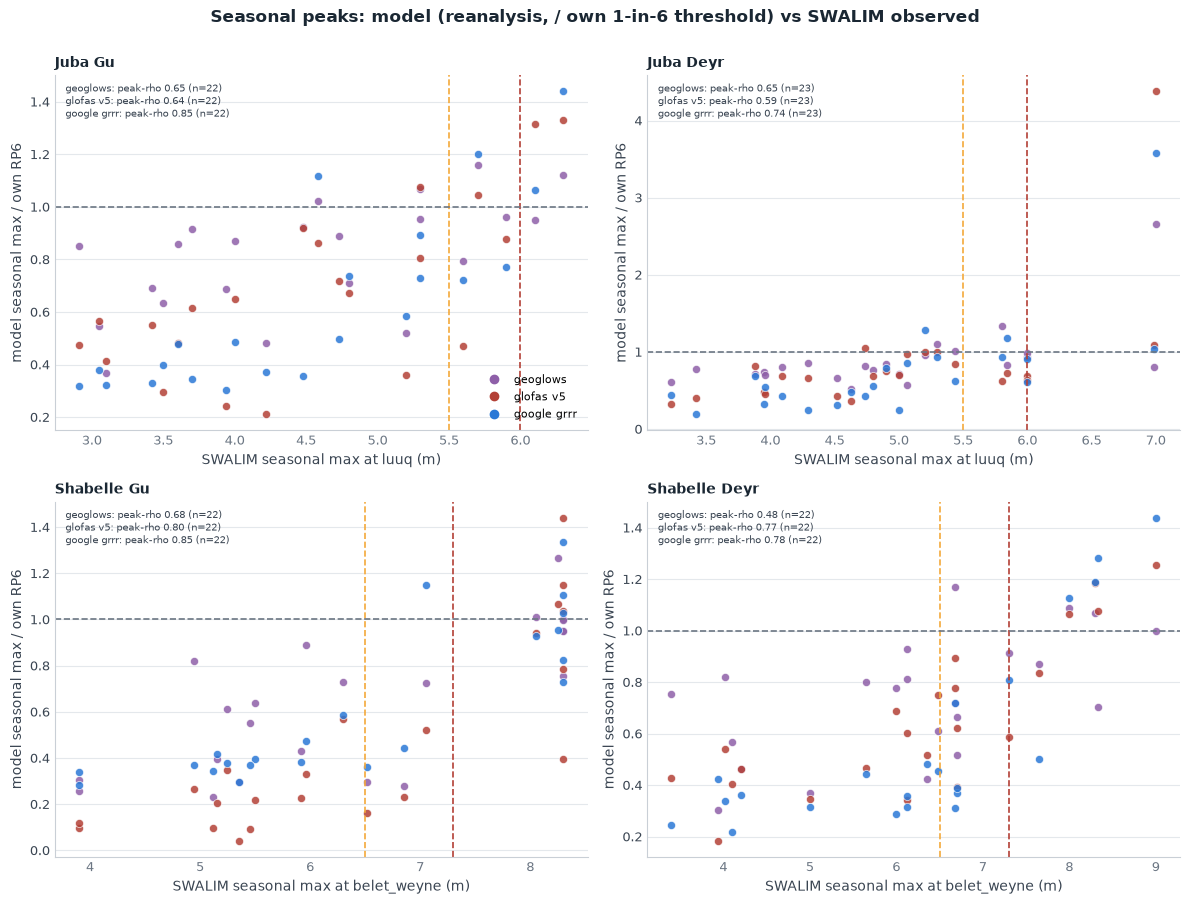

In [17]:
def swalim_peaks(river, season):
    g = REF_GAUGE[river]
    s = lv[lv.station == g].set_index("date")["level_m"]
    s = s[s.index.month.isin(SEASONS[season])]
    s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
    return s.groupby(s.index.year).max().dropna()

def spearman(x, y):
    return float(pd.Series(x).rank().corr(pd.Series(y).rank()))

def peak_panel(ax, river, season, model_peaks, title_extra=""):
    obs = swalim_peaks(river, season)
    mod_l = sw_th.loc[REF_GAUGE[river], "moderate_flood_risk"]
    high_l = sw_th.loc[REF_GAUGE[river], "high_flood_risk"]
    ax.axvline(mod_l, color="#F4A93B", lw=1.2, ls="--")
    ax.axvline(high_l, color="#B34036", lw=1.2, ls="--")
    ax.axhline(1.0, color=FAINT, lw=1.2, ls="--")
    labels = []
    for src, pk in model_peaks.items():
        common = obs.index.intersection(pk.index)
        if len(common) < 5:
            continue
        rho = spearman(obs.loc[common], pk.loc[common])
        ax.scatter(obs.loc[common], pk.loc[common], s=34,
                   color=SOURCE_COLORS[src], alpha=0.85,
                   edgecolors="white", linewidths=0.5)
        labels.append(f"{src.replace('_', ' ')}: peak-rho {rho:.2f} (n={len(common)})")
    ax.set_title(f"{river.capitalize()} {season.capitalize()}{title_extra}", fontsize=10)
    ax.set_xlabel(f"SWALIM seasonal max at {REF_GAUGE[river]} (m)")
    ax.set_ylabel("model seasonal max / own RP6")
    ax.text(0.02, 0.98, "\n".join(labels), transform=ax.transAxes, fontsize=7.5,
            va="top", color=BODY)
    style_ax(ax, grid="y")

# --- reanalysis peaks, normalised by own-reanalysis RP6 at the ref station
combos = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
SOURCES3 = ["geoglows", "glofas_v5", "google_grrr"]
peak_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (river, season) in zip(axes.ravel(), combos):
    months = SEASONS[season]
    mp = {}
    for src in SOURCES3:
        s = dd[(dd.file_source == src) & (dd.station == REF_GAUGE[river])].set_index("date")["discharge"]
        s = s[s.index.month.isin(months)]
        s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
        am = s.groupby(s.index.year).max().dropna()
        t = weibull_threshold(am.values, 6)
        mp[src] = am / t
        obs = swalim_peaks(river, season)
        common = obs.index.intersection(am.index)
        peak_rows.append({"river": river, "season": season, "source": src, "record": "reanalysis",
                          "n_years": len(common),
                          "peak_rho": round(spearman(obs.loc[common], am.loc[common]), 3)})
    peak_panel(ax, river, season, mp)
fig.suptitle("Seasonal peaks: model (reanalysis, / own 1-in-6 threshold) vs SWALIM observed",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
handles = [plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="",
                      label=s.replace("_", " ")) for s in SOURCES3]
axes.ravel()[0].legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
save_fig(fig, "i_peaks_reanalysis")
pd.DataFrame(peak_rows).pivot_table(index=["river", "season"], columns="source",
                                    values="peak_rho")


source                          geoglows  glofas_v5  google_grrr
river    season record                                          
juba     deyr   reanalysis         0.648      0.593        0.736
                reforecast<=6d       NaN      0.639        0.750
         gu     reanalysis         0.646      0.642        0.847
                reforecast<=6d       NaN      0.629        0.976
shabelle deyr   reanalysis         0.485      0.771        0.776
                reforecast<=6d       NaN      0.392        0.811
         gu     reanalysis         0.683      0.796        0.854
                reforecast<=6d       NaN      0.640        0.736

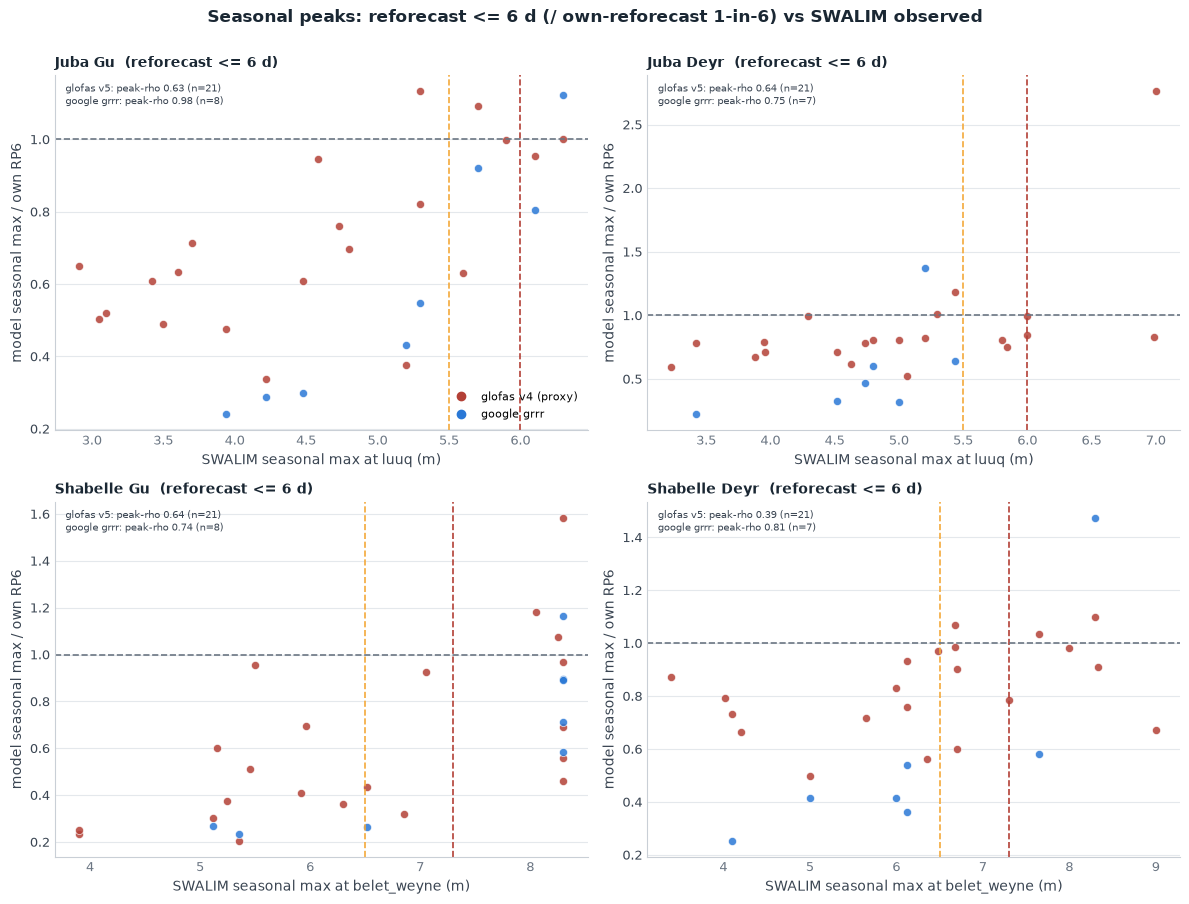

In [18]:
# --- reforecast (<= 6 d) peaks: what the operational signal's peaks look like.
# Normalised by the RP6 threshold fitted on the reforecast's OWN seasonal maxima
# (the assume-bias-for-all-sources rule); GRRR's 8-season archive makes its own
# RP6 unstable, so its normalisation carries a wide-uncertainty caveat.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (river, season) in zip(axes.ravel(), combos):
    months = SEASONS[season]
    mp = {}
    for src, tab in [("glofas_v5", RF["glofas_v4"]), ("google_grrr", RF["google_grrr"])]:
        s = tab[tab.station == REF_GAUGE[river]]
        s = s[s.valid_time.dt.month.isin(months)]
        pk = s.groupby(s.valid_time.dt.year)["q"].max().dropna()
        if len(pk) < 5:
            continue
        t = weibull_threshold(pk.values, 6)
        mp[src] = pk / t
        obs = swalim_peaks(river, season)
        common = obs.index.intersection(pk.index)
        peak_rows.append({"river": river, "season": season, "source": src, "record": "reforecast<=6d",
                          "n_years": len(common),
                          "peak_rho": round(spearman(obs.loc[common], pk.loc[common]), 3)})
    peak_panel(ax, river, season, mp, "  (reforecast <= 6 d)")
fig.suptitle("Seasonal peaks: reforecast <= 6 d (/ own-reforecast 1-in-6) vs SWALIM observed",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
handles = [plt.Line2D([], [], color=SOURCE_COLORS["glofas_v5"], marker="o", ls="",
                      label="glofas v4 (proxy)"),
           plt.Line2D([], [], color=SOURCE_COLORS["google_grrr"], marker="o", ls="",
                      label="google grrr")]
axes.ravel()[0].legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
save_fig(fig, "i_peaks_reforecast")
peaks_df = pd.DataFrame(peak_rows)
peaks_df.pivot_table(index=["river", "season", "record"], columns="source", values="peak_rho")


## J. Activations, impact and response, year by year

The two-historical-records rule: the trigger record against an **impact**
record, not just the hazard benchmark. Three independent(ish) sources:

- **EM-DAT** flood events (CRED; blob snapshot via ocha-stratus): deaths and
  people affected, attributed to basins by keyword on the event's Location
  text and to seasons by start month (3-6 -> Gu, 9-12 -> Deyr).
- **IDMC** disaster displacements (HDX, event-level, 2010-2025): flood
  displacement by region (event names carry the region -> basin) and month.
  Banadir/Bay/coastal/northern regions map to "other" (not riverine
  Juba/Shabelle).
- **CERF flood allocations** (aa.cerf_allocation mirror, dev DB): USD
  approved, window from the allocation date, basins by keyword on the
  narrative summaries.

Alongside, per basin: whether EACH indicator's consensus (that season's
station set and N-of-8 requirement, with the indicator's own RP6 thresholds
— GEOGloWS included, via its retrospective) would have activated, and the
SWALIM benchmark class of the year.


In [19]:
import io
import re
import requests

import ocha_stratus as stratus_db

JUBA_RE = r"juba|gedo|bardhe+re|baardheere|luuq|doo?low|bu'?aale|buale|saakow|jilib|kismayo|jamaame|dujuma"
SHAB_RE = r"sh?abell?e|hiraan|hiran|belet\s?weyne|beledweyne|bulo\s?burti|jowhar|balcad|afgooye|hirshabelle|wanla\s?weyn"

def basins_of(text):
    text = str(text)
    out = []
    if re.search(JUBA_RE, text, re.I):
        out.append("J")
    if re.search(SHAB_RE, text, re.I):
        out.append("S")
    return "+".join(out)

def season_of_month(m):
    if m in (3, 4, 5, 6):
        return "gu"
    if m in (9, 10, 11, 12):
        return "deyr"
    return None

# --- per-indicator activation years, per basin x season (own RP6 thresholds,
#     that season's station set and consensus requirement)
N_REQ = {(r, s): CONFIG[(r, s)]["n_req"] for (r, s) in CONFIG}
act_by_src = {}
for (river, season), c in CONFIG.items():
    months = SEASONS[season]
    for src in SOURCES3:
        cols = []
        for stn in c["stations"]:
            s = dd[(dd.file_source == src) & (dd.station == stn)].set_index("date")["discharge"]
            s = s[s.index.month.isin(months)]
            s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
            am = s.groupby(s.index.year).max().dropna()
            if not len(am):
                continue
            t = weibull_threshold(am.values, 6)
            if np.isnan(t):
                continue
            cols.append((s >= t).rename(stn))
        mat = pd.concat(cols, axis=1).fillna(False)
        mx = mat.sum(axis=1).groupby(mat.index.year).max()
        act_by_src[(river, season, src)] = set(mx[mx >= N_REQ[(river, season)]].index)
print({k: sorted(v) for k, v in act_by_src.items() if k[2] == "geoglows"})


{('juba', 'gu', 'geoglows'): [], ('juba', 'deyr', 'geoglows'): [2023], ('shabelle', 'gu', 'geoglows'): [2005, 2018], ('shabelle', 'deyr', 'geoglows'): []}


In [20]:
# --- EM-DAT floods
em = stratus_db.emdat.load_emdat_from_blob("som")
em = em[em["Disaster Type"].str.contains("Flood", case=False, na=False)].copy()
em["season"] = em["Start Month"].apply(lambda m: season_of_month(int(m)) if pd.notna(m) else None)
em["basins"] = (em["Location"].fillna("") + " " + em["Admin Units"].fillna("").astype(str)).apply(basins_of)
em_rows = []
for (y, se), g in em.groupby(["Start Year", "season"]):
    if se is None or not (YEARS[0] <= y <= YEARS[1]):
        continue
    em_rows.append({"year": int(y), "season": se,
                    "affected": int(g["Total Affected"].fillna(0).sum()),
                    "deaths": int(g["Total Deaths"].fillna(0).sum()),
                    "basins": "+".join(sorted(set("".join(g.basins.str.replace("+", ""))))) or "?"})
emdat_t = pd.DataFrame(em_rows)

# --- CERF flood allocations (aa.cerf_allocation mirror)
eng = stratus_db.get_engine(stage="dev")
cerf = pd.read_sql(
    """select application_code, year, emergency_type, amount_approved,
              first_project_approved_date, title, summary, humanitarian_overview
       from aa.cerf_allocation
       where country_iso3 = 'SOM' and emergency_type = 'Flood'""", eng)
cerf["month"] = pd.to_datetime(cerf.first_project_approved_date).dt.month
cerf["season"] = cerf.month.apply(season_of_month)
cerf["basins"] = (cerf.summary.fillna("") + " " + cerf.humanitarian_overview.fillna("")).apply(basins_of)
cerf_t = cerf[["application_code", "year", "season", "amount_approved", "basins"]]
print(cerf_t.to_string())

# --- IDMC flood displacement events (HDX)
IDMC_URL = ("https://data.humdata.org/dataset/c67f8253-b5c5-4f6c-ba34-9af41331d1f2/"
            "resource/fbcfcd16-6997-4212-ad1b-a2f7355624aa/download")
idmc = pd.read_csv(io.BytesIO(requests.get(IDMC_URL, timeout=120).content), skiprows=[1])
idmc = idmc[idmc.hazard_type_name.str.contains("Flood", case=False, na=False)].copy()
idmc["region"] = idmc.event_name.str.split(" - ").str[1].str.strip()
IDMC_BASIN = {"Gedo": "juba", "Middle Juba": "juba", "Lower Juba": "juba",
              "Hiraan": "shabelle", "Hiran": "shabelle",
              "Middle Shabelle": "shabelle", "Lower Shabelle": "shabelle"}
idmc["basin"] = idmc.region.map(IDMC_BASIN).fillna("other")
idmc["season"] = pd.to_datetime(idmc.start_date).dt.month.apply(season_of_month)
idmc_t = (idmc.dropna(subset=["season"])
          .groupby(["year", "basin", "season"]).new_displacement.sum()
          .astype(int).reset_index())
stratus_db.upload_parquet_to_blob(
    idmc_t, "ds-aa-som-floods/processed/workflow/som_impact_idmc.parquet", stage="dev")
idmc_t[idmc_t.year >= 2018].pivot_table(index="year", columns=["basin", "season"],
                                        values="new_displacement", aggfunc="sum").fillna(0).astype(int)


  application_code  year season  amount_approved basins
0  18-RR-SOM-30443  2018     gu        5133588.0       
1  06-RR-SOM-10626  2006   deyr       10437041.0       
2  19-RR-SOM-39722  2019   deyr        8000222.0    J+S
3  20-RR-SOM-43194  2020     gu        7100529.0      S
4  23-RR-SOM-61671  2023   deyr       10000009.0    J+S


basin     juba           other         shabelle        
season    deyr      gu    deyr      gu     deyr      gu
year                                                   
2018         0       0       0  289176        0       0
2019         0       0  406659    8995        0       0
2020         0       0  111017  504618        0       0
2021         0       0     108  101300        0       0
2022         0       0   11376      36        0      25
2023    604398  111809  346197   47053   335336  266135
2024      1060   38753     853   16486    14982   55908
2025         0     696       0    7242      192   37383

In [21]:
# --- assemble the year x (activation, impact, response) table
def act_letters(river, src):
    out = ""
    if any(y == year for y in act_by_src[(river, "gu", src)]):
        out += "G"
    if any(y == year for y in act_by_src[(river, "deyr", src)]):
        out += "D"
    return out

def bench_class(river, year):
    if year in basin_bench(river, "flood_5yr"):
        return "severe"
    if year in basin_bench(river, "flood_3yr"):
        return "moderate"
    return ""

table = []
for year in range(YEARS[0], YEARS[1] + 1):
    row = {"year": year, "act": {}, "bench": {}, "emdat": {}, "cerf": {}, "idmc": {}}
    for river in ("juba", "shabelle"):
        row["act"][river] = {src: act_letters(river, src) for src in SOURCES3}
        row["bench"][river] = bench_class(river, year)
        g = idmc_t[(idmc_t.year == year) & (idmc_t.basin == river)]
        row["idmc"][river] = {se: int(g[g.season == se].new_displacement.sum()) for se in ("gu", "deyr")}
    g = idmc_t[(idmc_t.year == year) & (idmc_t.basin == "other")]
    row["idmc"]["other"] = int(g.new_displacement.sum())
    for se in ("gu", "deyr"):
        e = emdat_t[(emdat_t.year == year) & (emdat_t.season == se)]
        row["emdat"][se] = ({"affected": int(e.affected.sum()), "deaths": int(e.deaths.sum()),
                             "basins": e.basins.iloc[0] if len(e) else ""}
                            if len(e) else None)
        c = cerf_t[(cerf_t.year == year) & (cerf_t.season == se)]
        row["cerf"][se] = ({"usd": int(c.amount_approved.sum()), "basins": c.basins.iloc[0]}
                           if len(c) else None)
    table.append(row)

meta = {"note": "activations on the calibration record (reanalysis/retrospective), "
                "each indicator against its own RP6 thresholds; IDMC coverage 2010-2025; "
                "EM-DAT is a floor; CERF amounts are national allocations",
        "n_req": {f"{r}_{s}": N_REQ[(r, s)] for (r, s) in N_REQ}}
out_json = {"meta": meta, "rows": table}
(FIGS.parent / "activation_impact.json").write_text(json.dumps(out_json, separators=(",", ":")))

flat = []
for row in table:
    fr = {"year": row["year"]}
    for river in ("juba", "shabelle"):
        for src in SOURCES3:
            fr[f"{river}_{src}"] = row["act"][river][src]
        fr[f"{river}_bench"] = row["bench"][river]
        fr[f"{river}_idmc_gu"] = row["idmc"][river]["gu"]
        fr[f"{river}_idmc_deyr"] = row["idmc"][river]["deyr"]
    for se in ("gu", "deyr"):
        fr[f"emdat_{se}_affected"] = row["emdat"][se]["affected"] if row["emdat"][se] else 0
        fr[f"cerf_{se}_usd"] = row["cerf"][se]["usd"] if row["cerf"][se] else 0
    flat.append(fr)
flat_df = pd.DataFrame(flat)
stratus_db.upload_parquet_to_blob(
    flat_df, "ds-aa-som-floods/processed/workflow/som_ms_activation_impact.parquet", stage="dev")
flat_df.to_parquet(DATA / "workflow" / "som_ms_activation_impact.parquet", index=False)
peaks_df.to_parquet(DATA / "workflow" / "som_ms_peak_correlations.parquet", index=False)
stratus_db.upload_parquet_to_blob(
    peaks_df, "ds-aa-som-floods/processed/workflow/som_ms_peak_correlations.parquet", stage="dev")
print("wrote pages/trigger/activation_impact.json + som_ms_activation_impact + som_ms_peak_correlations")
flat_df[flat_df.year >= 2016]


wrote pages/trigger/activation_impact.json + som_ms_activation_impact + som_ms_peak_correlations


,year,juba_geoglows,juba_glofas_v5,juba_google_grrr,juba_bench,juba_idmc_gu,juba_idmc_deyr,shabelle_geoglows,shabelle_glofas_v5,shabelle_google_grrr,shabelle_bench,shabelle_idmc_gu,shabelle_idmc_deyr,emdat_gu_affected,cerf_gu_usd,emdat_deyr_affected,cerf_deyr_usd
17,2016,,G,G,severe,0,0,,G,,severe,0,0,0,0,0,0
18,2017,,,,moderate,0,0,,,,,0,0,0,0,0,0
19,2018,,G,G,severe,0,0,G,G,G,moderate,0,0,700000,5133588,0,0
20,2019,,,D,,0,0,,D,D,severe,0,0,0,0,500000,8000222
21,2020,,G,G,severe,0,0,,G,G,severe,0,0,1191020,7100529,0,0
22,2021,,,,,0,0,,,,severe,0,0,400000,0,0,0
23,2022,,,,,0,0,,,,,25,0,4416,0,0,0
24,2023,D,D,D,severe,111809,604398,,D,D,severe,266135,335336,568003,0,2758000,10000009
